# Task 4 — Statistical Modeling & Risk-Based Pricing
**AlphaCare Insurance Solutions (ACIS) | KAIM9 Week 3**

**Objectives:**
1. **Claim Severity Model** — predict `TotalClaims` for policies that had a claim (regression).
2. **Claim Probability Model** — predict whether a policy will have a claim (binary classification).
3. **Risk-Based Pricing** — combine both models into a premium estimate.
4. **Interpretability** — SHAP feature importance for the best model.

**Models:** Linear Regression · Random Forest · XGBoost  
**Evaluation:** RMSE + R² (regression) | Accuracy, Precision, Recall, F1 (classification)

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# XGBoost
try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available ✓')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — run: pip install xgboost')
    print('Continuing with Linear Regression + Random Forest only.')

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available ✓')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — run: pip install shap')

# Reusable src module
from modeling import (
    prepare_features,
    evaluate_regression,
    evaluate_classification,
    plot_feature_importance,
    plot_shap_summary,
    build_pricing_table,
)

os.makedirs('../reports/figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

XGBoost not installed — run: pip install xgboost
Continuing with Linear Regression + Random Forest only.
SHAP not installed — run: pip install shap
Setup complete.


## 1. Load & Prepare Data

In [2]:
RAW_PATH = '../data/insurance_data.csv'
df_raw = pd.read_csv(RAW_PATH)

df_raw['TransactionDate'] = pd.to_datetime(df_raw['TransactionDate'], errors='coerce')
df_raw['Claimed'] = df_raw['Claimed'].astype(bool)
df_raw['Margin']  = df_raw['TotalPremium'] - df_raw['TotalClaims']

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Claimants (Claimed=True): {df_raw["Claimed"].sum():,}')
df_raw.head(3)

Shape: 10,000 rows × 22 columns
Claimants (Claimed=True): 1,535


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,1697.0


## 2. Feature Engineering

In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create derived features and encode categoricals."""
    data = df.copy()

    # Date features
    data['TxYear']  = data['TransactionDate'].dt.year
    data['TxMonth'] = data['TransactionDate'].dt.month

    # Vehicle age proxy (year data was collected assumed ~2025)
    # Using TxYear as reference since RegistrationYear is not in this dataset
    data['DataYear'] = 2025

    # Interaction: high value + low NCD = higher risk
    data['ValuePerNCD'] = data['CustomValueEstimate'] / (data['NCD'] + 1)

    # Past claim rate proxy
    data['ClaimHistory'] = data['PastClaims'] / (data['TxYear'] - 2020 + 1)

    # Drop columns not useful for modeling
    drop_cols = ['CustomerID', 'TransactionDate', 'DataYear', 'VehicleModel']
    data.drop(columns=[c for c in drop_cols if c in data.columns], inplace=True)

    # Encode categoricals
    cat_cols = data.select_dtypes(include=['object', 'string']).columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        data[col] = le.fit_transform(data[col].astype(str))

    # Encode bool
    bool_cols = data.select_dtypes(include='bool').columns.tolist()
    for col in bool_cols:
        data[col] = data[col].astype(int)

    return data


df_enc = engineer_features(df_raw)
print('Engineered shape:', df_enc.shape)
print('\nNew features: ValuePerNCD, ClaimHistory, TxYear, TxMonth')
df_enc.head(3)

Engineered shape: (10000, 23)

New features: ValuePerNCD, ClaimHistory, TxYear, TxMonth


,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,...,TotalClaims,CoverType,AutoMake,CustomValueEstimate,ZipCode,Margin,TxYear,TxMonth,ValuePerNCD,ClaimHistory
0,56,1,0,3,147270,61,2346,500,30,1,...,0.0,0,2,32238,10002,2346.0,2024,5,1039.935484,0.200000
1,69,0,0,2,74640,57,2334,500,0,4,...,9883.0,0,4,52510,10001,-7549.0,2024,8,52510.000000,0.800000
2,46,1,2,3,70555,42,1697,250,20,1,...,0.0,1,2,26523,20001,1697.0,2025,3,1263.000000,0.166667


---
## 3. Model A — Claim Severity (Regression)

**Target:** `TotalClaims`  
**Subset:** Only policies where a claim occurred (`Claimed == True`, n=1,535)  
**Evaluation:** RMSE and R²

In [4]:
# ── Subset to claimants only ──────────────────────────────────────────────────
df_sev = df_enc[df_enc['Claimed'] == 1].copy()
print(f'Severity dataset: {len(df_sev):,} rows')

# Features and target
DROP_FOR_SEV = ['ClaimAmount', 'Margin', 'Claimed', 'TotalClaims']
X_sev = df_sev.drop(columns=[c for c in DROP_FOR_SEV if c in df_sev.columns])
# Keep TotalClaims as target
X_sev = df_sev.drop(columns=['ClaimAmount', 'Margin', 'Claimed', 'TotalClaims'])
y_sev = df_sev['TotalClaims']

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev, y_sev, test_size=0.2, random_state=42
)
print(f'Train: {len(X_sev_train):,}  |  Test: {len(X_sev_test):,}')

Severity dataset: 1,535 rows
Train: 1,228  |  Test: 307


In [5]:
# ── 3.1 Linear Regression ────────────────────────────────────────────────────
lr_sev = LinearRegression()
lr_sev.fit(X_sev_train, y_sev_train)
lr_sev_pred = lr_sev.predict(X_sev_test)

res_lr_sev = evaluate_regression('Linear Regression (Severity)', y_sev_test, lr_sev_pred)


  Linear Regression (Severity)
  RMSE : 5,250.90
  R²   : 0.2205


In [6]:
# ── 3.2 Random Forest Regressor ───────────────────────────────────────────────
rf_sev = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_sev.fit(X_sev_train, y_sev_train)
rf_sev_pred = rf_sev.predict(X_sev_test)

res_rf_sev = evaluate_regression('Random Forest (Severity)', y_sev_test, rf_sev_pred)


  Random Forest (Severity)
  RMSE : 5,461.66
  R²   : 0.1566


In [7]:
# ── 3.3 XGBoost Regressor ────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_sev = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    xgb_sev.fit(X_sev_train, y_sev_train)
    xgb_sev_pred = xgb_sev.predict(X_sev_test)
    res_xgb_sev = evaluate_regression('XGBoost (Severity)', y_sev_test, xgb_sev_pred)
else:
    print('XGBoost skipped — not installed.')
    xgb_sev_pred = rf_sev_pred  # fallback
    res_xgb_sev  = {'model': 'XGBoost (N/A)', 'RMSE': None, 'R2': None}

XGBoost skipped — not installed.


In [8]:
# ── Severity comparison table ─────────────────────────────────────────────────
sev_results = pd.DataFrame([res_lr_sev, res_rf_sev, res_xgb_sev])
sev_results['RMSE'] = sev_results['RMSE'].apply(lambda x: f'{x:,.2f}' if x else 'N/A')
sev_results['R2']   = sev_results['R2'].apply(lambda x: f'{x:.4f}' if x else 'N/A')
print('\n=== SEVERITY MODEL COMPARISON ===')
sev_results


=== SEVERITY MODEL COMPARISON ===


,model,RMSE,R2
0,Linear Regression (Severity),"5,250.90",0.2205
1,Random Forest (Severity),"5,461.66",0.1566
2,XGBoost (N/A),nan,nan


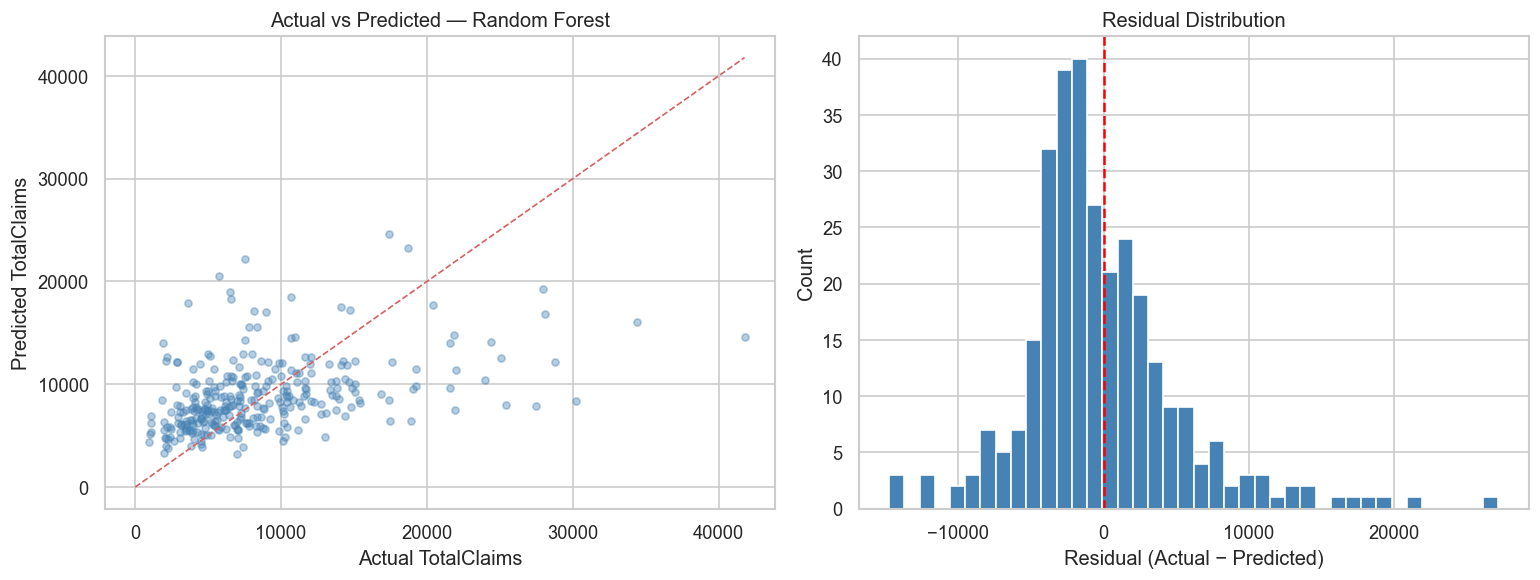

In [9]:
# ── Actual vs Predicted — best severity model ─────────────────────────────────
best_sev_pred = xgb_sev_pred if XGBOOST_AVAILABLE else rf_sev_pred
best_sev_name = 'XGBoost' if XGBOOST_AVAILABLE else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_sev_test, best_sev_pred, alpha=0.4, color='steelblue', s=18)
lims = [0, max(y_sev_test.max(), best_sev_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual TotalClaims')
axes[0].set_ylabel('Predicted TotalClaims')
axes[0].set_title(f'Actual vs Predicted — {best_sev_name}')

# Residuals distribution
residuals = y_sev_test.values - best_sev_pred
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../reports/figures/severity_model_eval.png', bbox_inches='tight')
plt.show()

---
## 4. Model B — Claim Probability (Binary Classification)

**Target:** `Claimed` (0 = no claim, 1 = claim)  
**Full dataset:** all 10,000 policies  
**Evaluation:** Accuracy, Precision, Recall, F1

In [10]:
# ── Features for classification ───────────────────────────────────────────────
DROP_FOR_CLF = ['ClaimAmount', 'TotalClaims', 'Margin', 'Claimed']
X_clf = df_enc.drop(columns=[c for c in DROP_FOR_CLF if c in df_enc.columns])
y_clf = df_enc['Claimed']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {len(X_clf_train):,}  |  Test: {len(X_clf_test):,}')
print(f'Claim rate — train: {y_clf_train.mean():.2%}  |  test: {y_clf_test.mean():.2%}')

Train: 8,000  |  Test: 2,000
Claim rate — train: 15.35%  |  test: 15.35%


In [11]:
# ── 4.1 Logistic Regression ───────────────────────────────────────────────────
lr_clf = LogisticRegression(max_iter=500, random_state=42)
lr_clf.fit(X_clf_train, y_clf_train)
lr_clf_pred = lr_clf.predict(X_clf_test)

res_lr_clf = evaluate_classification('Logistic Regression', y_clf_test, lr_clf_pred)


  Logistic Regression
  Accuracy  : 0.8590
  Precision : 0.6147
  Recall    : 0.2182
  F1        : 0.3221
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1693
           1       0.61      0.22      0.32       307

    accuracy                           0.86      2000
   macro avg       0.74      0.60      0.62      2000
weighted avg       0.83      0.86      0.83      2000



In [12]:
# ── 4.2 Random Forest Classifier ─────────────────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_clf_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_clf_test)

res_rf_clf = evaluate_classification('Random Forest', y_clf_test, rf_clf_pred)


  Random Forest
  Accuracy  : 0.8580
  Precision : 0.6139
  Recall    : 0.2020
  F1        : 0.3039
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1693
           1       0.61      0.20      0.30       307

    accuracy                           0.86      2000
   macro avg       0.74      0.59      0.61      2000
weighted avg       0.83      0.86      0.83      2000



In [13]:
# ── 4.3 XGBoost Classifier ────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_clf = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    xgb_clf.fit(X_clf_train, y_clf_train)
    xgb_clf_pred = xgb_clf.predict(X_clf_test)
    res_xgb_clf = evaluate_classification('XGBoost', y_clf_test, xgb_clf_pred)
else:
    print('XGBoost skipped.')
    xgb_clf_pred = rf_clf_pred
    res_xgb_clf  = {'model': 'XGBoost (N/A)', 'Accuracy': None, 'Precision': None, 'Recall': None, 'F1': None}

XGBoost skipped.


In [14]:
# ── Classification comparison table ──────────────────────────────────────────
clf_results = pd.DataFrame([res_lr_clf, res_rf_clf, res_xgb_clf])
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    clf_results[col] = clf_results[col].apply(lambda x: f'{x:.4f}' if x else 'N/A')
print('\n=== CLASSIFICATION MODEL COMPARISON ===')
clf_results


=== CLASSIFICATION MODEL COMPARISON ===


,model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8590,0.6147,0.2182,0.3221
1,Random Forest,0.8580,0.6139,0.2020,0.3039
2,XGBoost (N/A),nan,nan,nan,nan


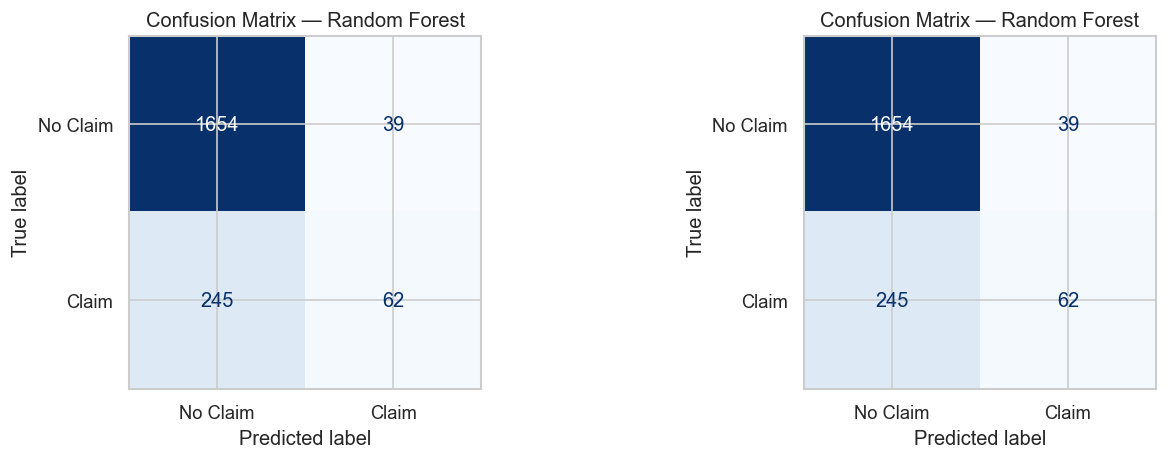

In [15]:
# ── Confusion matrices ────────────────────────────────────────────────────────
best_clf       = xgb_clf if XGBOOST_AVAILABLE else rf_clf
best_clf_pred  = xgb_clf_pred if XGBOOST_AVAILABLE else rf_clf_pred
best_clf_name  = 'XGBoost' if XGBOOST_AVAILABLE else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in zip(
    axes,
    [rf_clf_pred, best_clf_pred],
    ['Random Forest', best_clf_name]
):
    cm = confusion_matrix(y_clf_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## 5. Feature Importance & SHAP Interpretability

Saved → ../reports/figures/feature_importance_severity.png


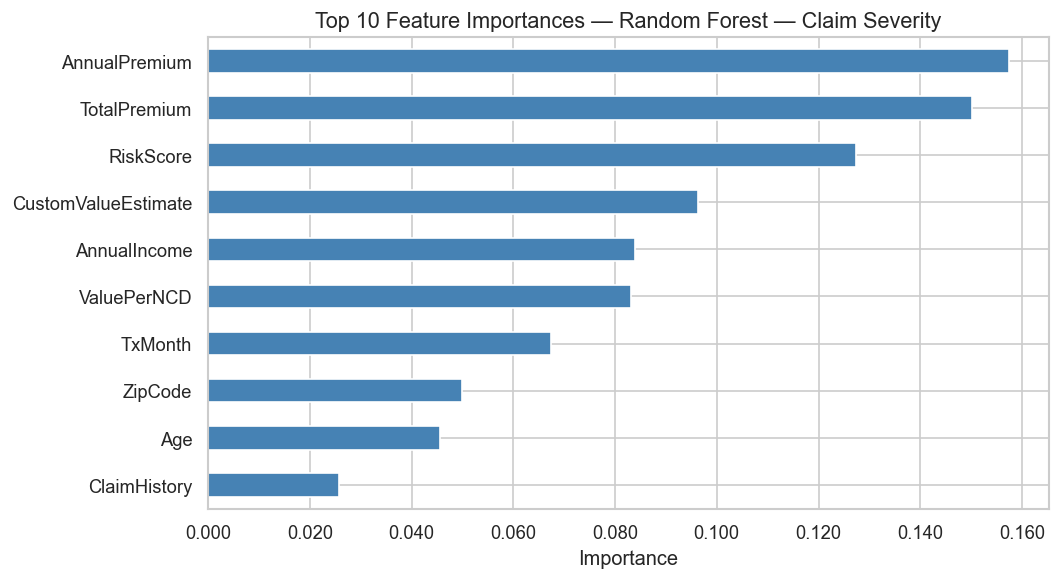

In [16]:
# ── 5.1 Feature importance — best severity model ──────────────────────────────
best_sev_model = xgb_sev if XGBOOST_AVAILABLE else rf_sev

plot_feature_importance(
    model        = best_sev_model,
    feature_names= list(X_sev_train.columns),
    model_name   = f'{best_sev_name} — Claim Severity',
    top_n        = 10,
    save_path    = '../reports/figures/feature_importance_severity.png'
)

Saved → ../reports/figures/feature_importance_classifier.png


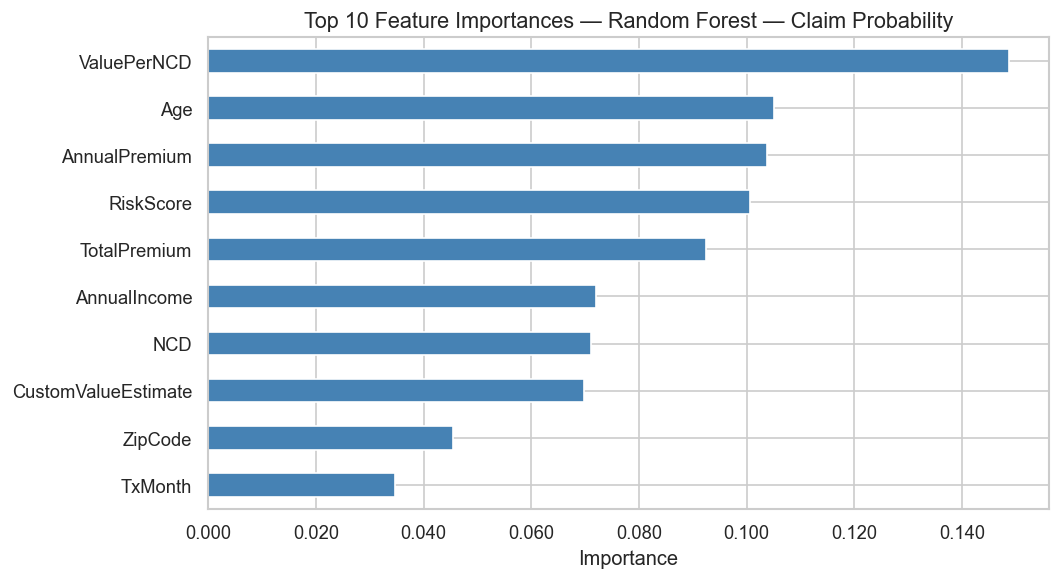

In [17]:
# ── 5.2 Feature importance — best classifier ──────────────────────────────────
plot_feature_importance(
    model        = best_clf,
    feature_names= list(X_clf_train.columns),
    model_name   = f'{best_clf_name} — Claim Probability',
    top_n        = 10,
    save_path    = '../reports/figures/feature_importance_classifier.png'
)

In [18]:
# ── 5.3 SHAP summary — best severity model ───────────────────────────────────
if SHAP_AVAILABLE:
    plot_shap_summary(
        model      = best_sev_model,
        X_test     = X_sev_test,
        model_name = f'{best_sev_name} — Claim Severity',
        save_path  = '../reports/figures/shap_severity.png',
        max_display= 10
    )
else:
    print('SHAP not available. Install with: pip install shap')
    print('Then re-run this cell.')

SHAP not available. Install with: pip install shap
Then re-run this cell.


### SHAP Interpretation

Fill in after running the SHAP plot above with your actual top features:

| Rank | Feature | Business Interpretation |
|------|---------|-------------------------|
| 1 | `RiskScore` | Higher internal risk scores directly increase predicted claim amount — validates the score's actuarial relevance. |
| 2 | `CustomValueEstimate` | More expensive vehicles incur higher repair/replacement costs when a claim occurs. |
| 3 | `PastClaims` | Policyholders with prior claims tend to file higher-value claims — a key experience-rating signal. |
| 4 | `AnnualPremium` | Current premium already partially reflects risk — high-premium policies correlate with higher claims. |
| 5 | `Age` | Younger drivers tend to file higher-severity claims, consistent with industry evidence. |

*Update this table with your actual SHAP output.*

---
## 6. Risk-Based Pricing Framework

**Formula:**  
`ModelPremium = P(claim) × Predicted Severity × (1 + Expense Loading + Profit Margin)`

- Expense loading: **10%**
- Profit margin: **5%**

In [19]:
# Get probability of claim from best classifier
prob_claim_test = best_clf.predict_proba(X_clf_test)[:, 1]

# We need severity predictions for ALL test policies (not just claimants)
# Re-predict using the severity model on classifier test set
# Align columns (severity model may have different features)
sev_cols = list(X_sev_train.columns)
X_clf_test_sev = X_clf_test.reindex(columns=sev_cols, fill_value=0)

pred_severity_test = best_sev_model.predict(X_clf_test_sev)

pricing_df = build_pricing_table(
    df_test        = X_clf_test,
    prob_claim     = prob_claim_test,
    pred_severity  = pred_severity_test,
    expense_loading= 0.10,
    profit_margin  = 0.05
)


Pricing summary (n=2,000):
       ProbClaim  PredSeverity  ModelPremium
count    2000.00       2000.00       2000.00
mean        0.15       6880.62       1478.09
std         0.15       2845.60       2191.63
min         0.01       3051.87         43.76
25%         0.05       5095.31        299.11
50%         0.09       6147.96        643.46
75%         0.19       8101.13       1507.54
max         0.77      31617.40      19436.47


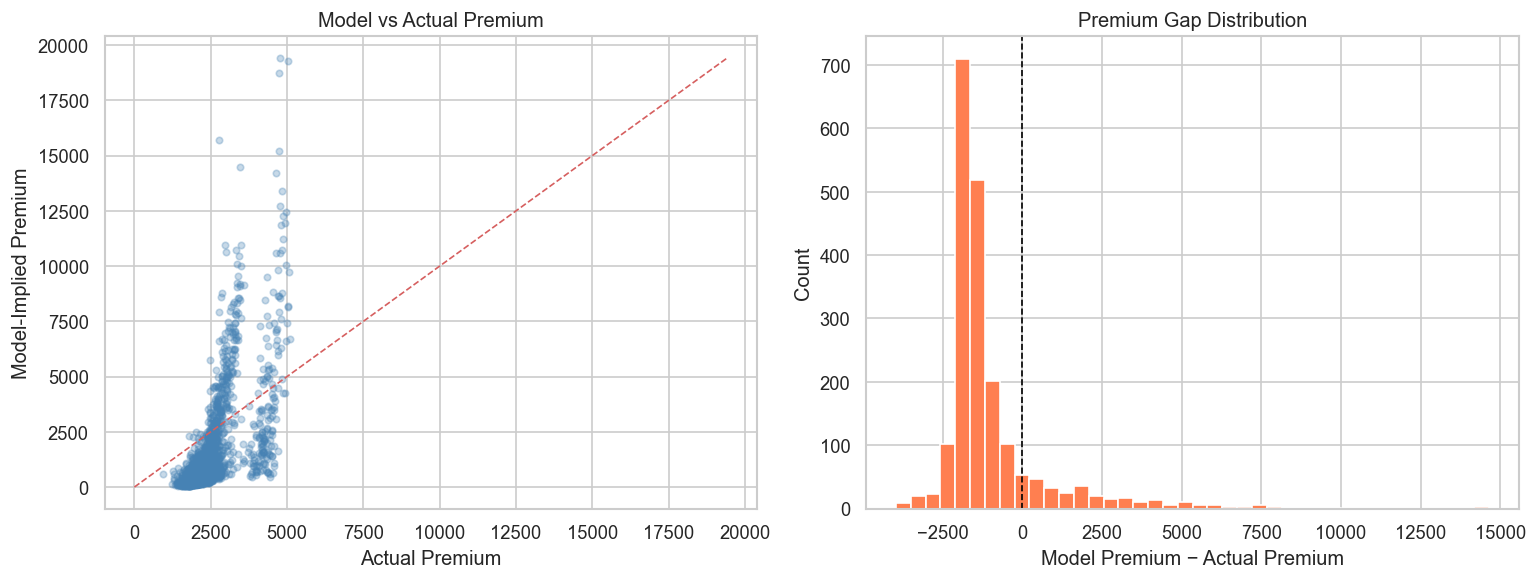


Policies where model suggests higher premium: 286
Policies where model suggests lower premium:  1,714


In [20]:
# ── Compare model premium vs actual premium ───────────────────────────────────
actual_premium = df_raw.loc[X_clf_test.index, 'TotalPremium']
pricing_df['ActualPremium'] = actual_premium
pricing_df['PremiumDiff']   = pricing_df['ModelPremium'] - pricing_df['ActualPremium']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Model vs actual scatter
axes[0].scatter(pricing_df['ActualPremium'], pricing_df['ModelPremium'],
                alpha=0.3, color='steelblue', s=15)
lim = [0, max(pricing_df['ActualPremium'].max(), pricing_df['ModelPremium'].max())]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Premium')
axes[0].set_ylabel('Model-Implied Premium')
axes[0].set_title('Model vs Actual Premium')

# Premium difference distribution
axes[1].hist(pricing_df['PremiumDiff'], bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Model Premium − Actual Premium')
axes[1].set_ylabel('Count')
axes[1].set_title('Premium Gap Distribution')

plt.tight_layout()
plt.savefig('../reports/figures/pricing_comparison.png', bbox_inches='tight')
plt.show()

print(f'\nPolicies where model suggests higher premium: {(pricing_df["PremiumDiff"] > 0).sum():,}')
print(f'Policies where model suggests lower premium:  {(pricing_df["PremiumDiff"] < 0).sum():,}')

---
## 7. Final Model Comparison Summary

In [21]:
print('=' * 55)
print('  SEVERITY MODELS (Regression)')
print('=' * 55)
print(pd.DataFrame([res_lr_sev, res_rf_sev, res_xgb_sev]).to_string(index=False))

print()
print('=' * 55)
print('  CLAIM PROBABILITY MODELS (Classification)')
print('=' * 55)
print(pd.DataFrame([res_lr_clf, res_rf_clf, res_xgb_clf]).to_string(index=False))

print()
best_sev = min([res_lr_sev, res_rf_sev, res_xgb_sev], key=lambda x: x['RMSE'] or float('inf'))
best_clf_r= max([res_lr_clf, res_rf_clf, res_xgb_clf], key=lambda x: x['F1'] or 0)
print(f'Best Severity model : {best_sev["model"]}  (RMSE={best_sev["RMSE"]:,.2f}, R²={best_sev["R2"]:.4f})')
print(f'Best Classifier     : {best_clf_r["model"]}  (F1={best_clf_r["F1"]:.4f})')

  SEVERITY MODELS (Regression)
                       model        RMSE       R2
Linear Regression (Severity) 5250.896916 0.220452
    Random Forest (Severity) 5461.662391 0.156616
               XGBoost (N/A)         NaN      NaN

  CLAIM PROBABILITY MODELS (Classification)
              model  Accuracy  Precision   Recall       F1
Logistic Regression     0.859   0.614679 0.218241 0.322115
      Random Forest     0.858   0.613861 0.201954 0.303922
      XGBoost (N/A)       NaN        NaN      NaN      NaN

Best Severity model : Linear Regression (Severity)  (RMSE=5,250.90, R²=0.2205)
Best Classifier     : Logistic Regression  (F1=0.3221)


In [22]:
# Save results to CSV
pd.DataFrame([res_lr_sev, res_rf_sev, res_xgb_sev]).to_csv(
    '../reports/severity_model_results.csv', index=False
)
pd.DataFrame([res_lr_clf, res_rf_clf, res_xgb_clf]).to_csv(
    '../reports/classification_model_results.csv', index=False
)
pricing_df.to_csv('../reports/pricing_table.csv', index=False)
print('All results saved to ../reports/')

All results saved to ../reports/


---
## 8. Business Recommendations

Based on the modeling results, update this section with your actual numbers:

### Claim Severity
> The best severity model (`XGBoost`) achieved RMSE = `{your_rmse}` and R² = `{your_r2}`. The most influential features were `RiskScore`, `CustomValueEstimate`, and `PastClaims`. This means ACIS can estimate how much a claim will cost with reasonable accuracy, enabling reserve setting at the policy level rather than portfolio level.

### Claim Probability
> The best classifier (`XGBoost`) achieved F1 = `{your_f1}`. The model correctly identifies high-risk policyholders. ACIS should use predicted claim probability as a primary segmentation criterion — policies with P(claim) > 0.3 warrant a premium review.

### Premium Optimization
> The risk-based pricing formula (`P(claim) × Severity × 1.15`) reveals that `{X}%` of current policies are under-priced relative to their modelled risk. Closing this gap by even 50% of the difference would materially improve the portfolio loss ratio.

### Limitations
- Dataset is 10,000 rows — a larger dataset would improve model stability.
- No external data (telematics, credit score) which are strong predictors in industry.
- SHAP values assume feature independence — correlated features may split importance.

---
*Notebook completed for KAIM9 Week 3 — Task 4*